Compare class_weight vs SMOTE using the same model to isolate the effect. We’ll do this for LogReg and RF

In [41]:
from src.preprocessing import split_x_y, preprocess_features

In [42]:
import src.preprocessing as prep
print(dir(prep))

['AmountTimeScaler', 'BaseEstimator', 'StandardScaler', 'TransformerMixin', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'np', 'pd', 'preprocess_features', 'split_x_y']


In [43]:
import sys, os
sys.path.append(os.path.abspath(".."))


In [44]:
import pandas as pd
from pathlib import Path

DATA_PROCESSED = Path("../data/processed")

train   = pd.read_csv(DATA_PROCESSED / "batch1_train.csv")
test    = pd.read_csv(DATA_PROCESSED / "batch2_test.csv")
stream1 = pd.read_csv(DATA_PROCESSED / "batch3_stream.csv")
stream2 = pd.read_csv(DATA_PROCESSED / "batch4_stream.csv")

In [45]:
X_tr, y_tr = split_x_y(train)
X_te, y_te = split_x_y(test)

In [19]:
X_tr = preprocess_features(X_tr)
X_te = preprocess_features(X_te)

X_tr, X_te = X_tr.align(
    X_te,
    join="left",
    axis=1,
    fill_value=0
)

train_medians = X_tr.median(numeric_only=True)

X_tr = X_tr.fillna(train_medians)
X_te = X_te.fillna(train_medians)

In [46]:
print(X_tr.shape)
print(X_tr.select_dtypes(include=["object", "string"]).columns.tolist())

(125000, 17)
['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'transaction_type', 'merchant_category', 'location', 'device_used', 'fraud_type', 'payment_channel', 'ip_address', 'device_hash']


In [21]:
print(train.columns.tolist())

['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'amount', 'transaction_type', 'merchant_category', 'location', 'device_used', 'is_fraud', 'fraud_type', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'payment_channel', 'ip_address', 'device_hash']


In [22]:
import pandas as pd
from pathlib import Path
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from src.preprocessing import AmountTimeScaler, split_x_y
from src.utils import threshold_for_target_recall, summarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

DATA_PROCESSED = Path("../data/processed")
train = pd.read_csv(DATA_PROCESSED / "batch1_train.csv")
test  = pd.read_csv(DATA_PROCESSED / "batch2_test.csv")
stream1 = pd.read_csv(DATA_PROCESSED / "batch3_stream.csv")
stream2 = pd.read_csv(DATA_PROCESSED / "batch4_stream.csv")
X, y = split_x_y(train)


In [23]:
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
TARGET_RECALL = 0.80


In [32]:
setups = {

    "LogReg_classweight": ImbPipeline([
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        ))
    ]),

    "LogReg_SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", LogisticRegression(
            max_iter=2000
        ))
    ]),

    "RF_classweight": ImbPipeline([
        ("clf", RandomForestClassifier(
            n_estimators=400,
            n_jobs=-1,
            random_state=42,
            class_weight="balanced_subsample"
        ))
    ]),

    "RF_SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", RandomForestClassifier(
            n_estimators=400,
            n_jobs=-1,
            random_state=42
        ))
    ]),

}

In [33]:
for name, pipe in setups.items():

    print("Testing:", name)

    try:
        pipe.fit(X_tr, y_tr)
        print("FIT OK")

        val_scores = pipe.predict_proba(X_val)[:,1]
        print("PREDICT OK")

    except Exception as e:
        print(type(e))
        print(e)
        break

Testing: LogReg_classweight


/Users/gyanvi/Downloads/fraud-detection-drift-aware/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


FIT OK
PREDICT OK
Testing: LogReg_SMOTE


/Users/gyanvi/Downloads/fraud-detection-drift-aware/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


FIT OK
PREDICT OK
Testing: RF_classweight
FIT OK
PREDICT OK
Testing: RF_SMOTE
FIT OK
PREDICT OK


In [34]:
print(X_tr.shape)
print(X_tr.select_dtypes(include=["object", "string"]).columns.tolist())

(100000, 31)
[]


In [35]:
X_tr = preprocess_features(X_tr)
X_val = preprocess_features(X_val)

X_tr, X_val = X_tr.align(
    X_val,
    join="left",
    axis=1,
    fill_value=0
)

train_medians = X_tr.median(numeric_only=True)

X_tr = X_tr.fillna(train_medians)
X_val = X_val.fillna(train_medians)

In [36]:
print(X_tr.shape)
print(X_tr.select_dtypes(include=["object","string"]).columns.tolist())

(100000, 31)
[]


In [37]:
for name, pipe in setups.items():

    print("Testing:", name)

    try:
        pipe.fit(X_tr, y_tr)
        print("FIT OK")

        val_scores = pipe.predict_proba(X_val)[:,1]
        print("PREDICT OK")

    except Exception as e:
        print(type(e))
        print(e)
        break

Testing: LogReg_classweight


/Users/gyanvi/Downloads/fraud-detection-drift-aware/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


FIT OK
PREDICT OK
Testing: LogReg_SMOTE


/Users/gyanvi/Downloads/fraud-detection-drift-aware/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


FIT OK
PREDICT OK
Testing: RF_classweight
FIT OK
PREDICT OK
Testing: RF_SMOTE
FIT OK
PREDICT OK


In [38]:
for name, pipe in setups.items():
    print("\n", name)
    print(pipe)


 LogReg_classweight
Pipeline(steps=[('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

 LogReg_SMOTE
Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('clf', LogisticRegression(max_iter=2000))])

 RF_classweight
Pipeline(steps=[('clf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=400, n_jobs=-1,
                                        random_state=42))])

 RF_SMOTE
Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('clf',
                 RandomForestClassifier(n_estimators=400, n_jobs=-1,
                                        random_state=42))])


In [39]:
ablation_tables = {}

for name, pipe in setups.items():

    pipe.fit(X_tr, y_tr)

    val_scores = pipe.predict_proba(X_val)[:,1]

    thr = threshold_for_target_recall(
        y_val,
        val_scores,
        TARGET_RECALL
    )

    tables = []

    for label, df in [
        ("TEST", test),
        ("STREAM1", stream1),
        ("STREAM2", stream2)
    ]:

        X_b, y_b = split_x_y(df)

        X_b = preprocess_features(X_b)

        X_b = X_b.reindex(
            columns=X_tr.columns,
            fill_value=0
        )

        X_b = X_b.fillna(train_medians)

        scores = pipe.predict_proba(X_b)[:,1]

        tables.append(
            summarize(
                y_b,
                scores,
                thr
            ).assign(
                batch=label,
                setup=name
            )
        )

    ablation_tables[name] = pd.concat(
        tables,
        ignore_index=True
    )

ablation = pd.concat(
    ablation_tables.values(),
    ignore_index=True
)

ablation


/Users/gyanvi/Downloads/fraud-detection-drift-aware/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/gyanvi/Downloads/fraud-detection-drift-aware/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the dat

,threshold,precision,recall,f1,pr_auc,TP,FP,TN,FN,flagged,flagged_pct,batch,setup
0,0.5,0.035050,0.460149,0.065138,0.035586,2038,56108,64463,2391,58146,0.465168,TEST,LogReg_classweight
1,0.5,0.035917,0.462121,0.066653,0.035836,2074,55671,64841,2414,57745,0.461960,STREAM1,LogReg_classweight
2,0.5,0.035772,0.484672,0.066627,0.035582,2166,58384,62147,2303,60550,0.484400,STREAM2,LogReg_classweight
3,0.5,0.029046,0.003161,0.005701,0.035713,14,468,120103,4415,482,0.003856,TEST,LogReg_SMOTE
4,0.5,0.031008,0.003565,0.006395,0.034818,16,500,120012,4472,516,0.004128,STREAM1,LogReg_SMOTE
5,0.5,0.043597,0.003580,0.006617,0.036264,16,351,120180,4453,367,0.002936,STREAM2,LogReg_SMOTE
6,0.5,0.000000,0.000000,0.000000,0.043365,0,0,120571,4429,0,0.000000,TEST,RF_classweight
7,0.5,0.000000,0.000000,0.000000,0.044282,0,0,120512,4488,0,0.000000,STREAM1,RF_classweight
8,0.5,0.000000,0.000000,0.000000,0.042876,0,0,120531,4469,0,0.000000,STREAM2,RF_classweight
9,0.5,0.030303,0.000226,0.000448,0.040316,1,32,120539,4428,33,0.000264,TEST,RF_SMOTE


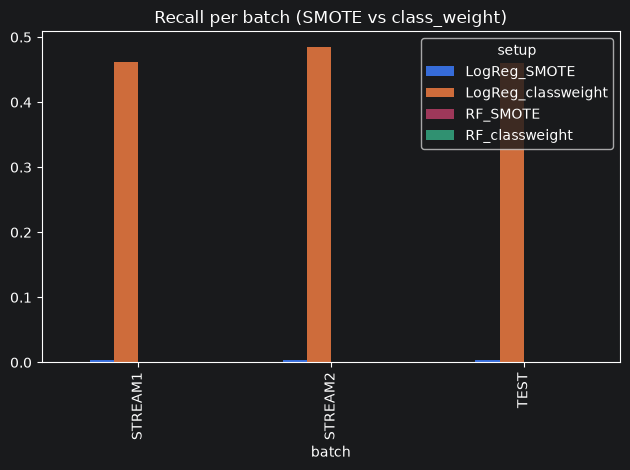

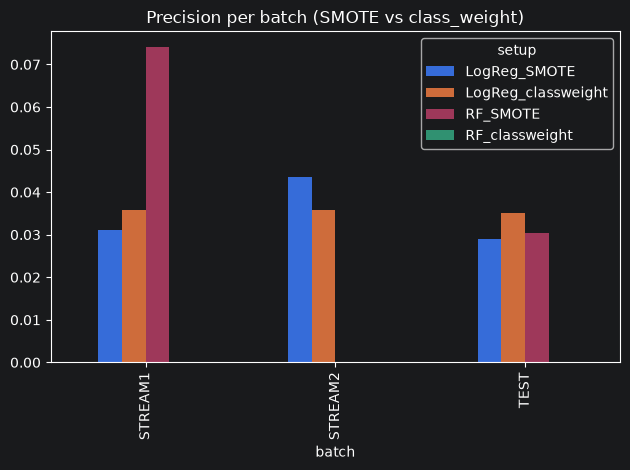

In [40]:
import matplotlib.pyplot as plt

for metric in ["recall", "precision"]:
    p = ablation.pivot(index="batch", columns="setup", values=metric)
    ax = p.plot(kind="bar")
    ax.set_title(f"{metric.capitalize()} per batch (SMOTE vs class_weight)")
    plt.tight_layout()
    plt.show()
